Setup und Daten laden

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("C:/Users/demyi/Downloads/archive/healthcare_dataset.csv")

# Datum umwandeln & Verweildauer berechnen
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])
df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

Preprocessing

In [7]:
# 2. Features auswählen und skalieren/kodieren
numeric_features = ["Age", "Billing Amount", "Length of Stay"]
categorical_features = ["Gender", "Blood Type", "Medical Condition", "Admission Type", "Test Results"]

# Wir bauen direkt den hochdimensionalen, überlappenden Datensatz
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
    ]
)
X_full = preprocessor.fit_transform(df)
print(f"Datensatz bereit zur Analyse. Shape: {X_full.shape}")

Datensatz bereit zur Analyse. Shape: (55500, 20)


Die Kern-Funktionen für die Metriken

In [ ]:
# 3. Hilfsfunktionen zur objektiven Bestimmung von k definieren
K_RANGE = range(2, 11)

def compute_metrics(X, k_range=K_RANGE, random_state=42):
    """Berechnet Inertia und Silhouette für alle k."""
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=random_state)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))
    return np.array(inertias), np.array(silhouettes)

def kneedle_elbow(k_values, inertias):
    k_values, y = np.array(k_values, dtype=float), np.array(inertias, dtype=float)
    x_norm = (k_values - k_values.min()) / (k_values.max() - k_values.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    line = y_norm[0] + (y_norm[-1] - y_norm[0]) * (x_norm - x_norm[0]) / (x_norm[-1] - x_norm[0])
    return int(k_values[np.argmax(line - y_norm)])

def silhouette_best_k(k_values, silhouettes):
    return int(np.array(k_values)[np.argmax(silhouettes)])

def consistency_rate(k_array):
    values, counts = np.unique(k_array, return_counts=True)
    return counts.max() / len(k_array), values[np.argmax(counts)]

Das Robustheits-Experiment

In [ ]:
# 4. Bootstrap-Experiment durchführen
B = 30
BOOT_SAMPLE_SIZE = 1500

boot_k_elbow, boot_k_sil = [], []

for b in range(B):
    # Ziehe zufällige Stichprobe
    rng_b = np.random.RandomState(b)
    idx_b = rng_b.choice(len(df), size=BOOT_SAMPLE_SIZE, replace=False)
    X_b = X_full[idx_b]

    # Berechne Metriken und bestimme optimales k
    inertias_b, silhouettes_b = compute_metrics(X_b, random_state=b)
    boot_k_elbow.append(kneedle_elbow(list(K_RANGE), inertias_b))
    boot_k_sil.append(silhouette_best_k(list(K_RANGE), silhouettes_b))

boot_k_elbow = np.array(boot_k_elbow)
boot_k_sil = np.array(boot_k_sil)
print("Experiment abgeschlossen!")

Starte 30 Bootstrap-Wiederholungen. Bitte warten...
Experiment abgeschlossen!


Auswertung

,Metrik,Modus (häufigstes k),Standardabweichung Std(k),Konsistenzrate
0,Ellbogen-Methode,6,0.496,56.7%
1,Silhouettenkoeffizient,2,0.499,93.3%


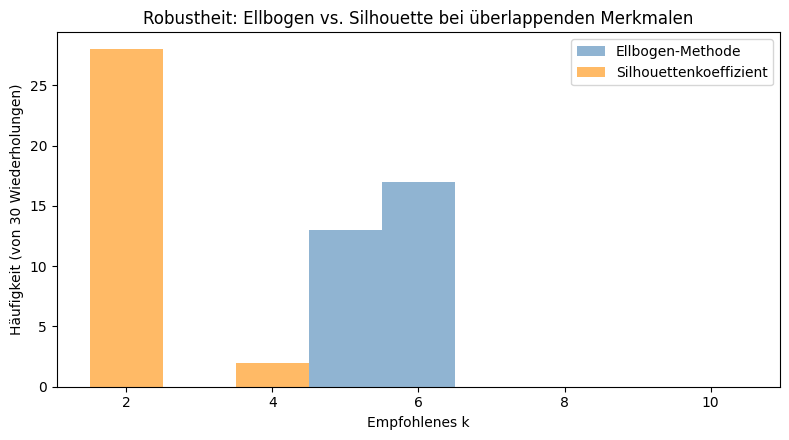

In [10]:
# 5. Finale Gegenüberstellung
rate_elbow, mode_elbow = consistency_rate(boot_k_elbow)
rate_sil, mode_sil = consistency_rate(boot_k_sil)

summary = pd.DataFrame({
    "Metrik": ["Ellbogen-Methode", "Silhouettenkoeffizient"],
    "Modus (häufigstes k)": [mode_elbow, mode_sil],
    "Standardabweichung Std(k)": [round(boot_k_elbow.std(), 3), round(boot_k_sil.std(), 3)],
    "Konsistenzrate": [f"{rate_elbow:.1%}", f"{rate_sil:.1%}"]
})
display(summary)

# Visualisierung
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(1.5, 11.5, 1)
ax.hist(boot_k_elbow, bins=bins, alpha=0.6, label="Ellbogen-Methode", color="steelblue")
ax.hist(boot_k_sil, bins=bins, alpha=0.6, label="Silhouettenkoeffizient", color="darkorange")
ax.set_xlabel("Empfohlenes k")
ax.set_ylabel(f"Häufigkeit (von {B} Wiederholungen)")
ax.set_title("Robustheit: Ellbogen vs. Silhouette bei überlappenden Merkmalen")
ax.legend()
plt.tight_layout()
plt.show()

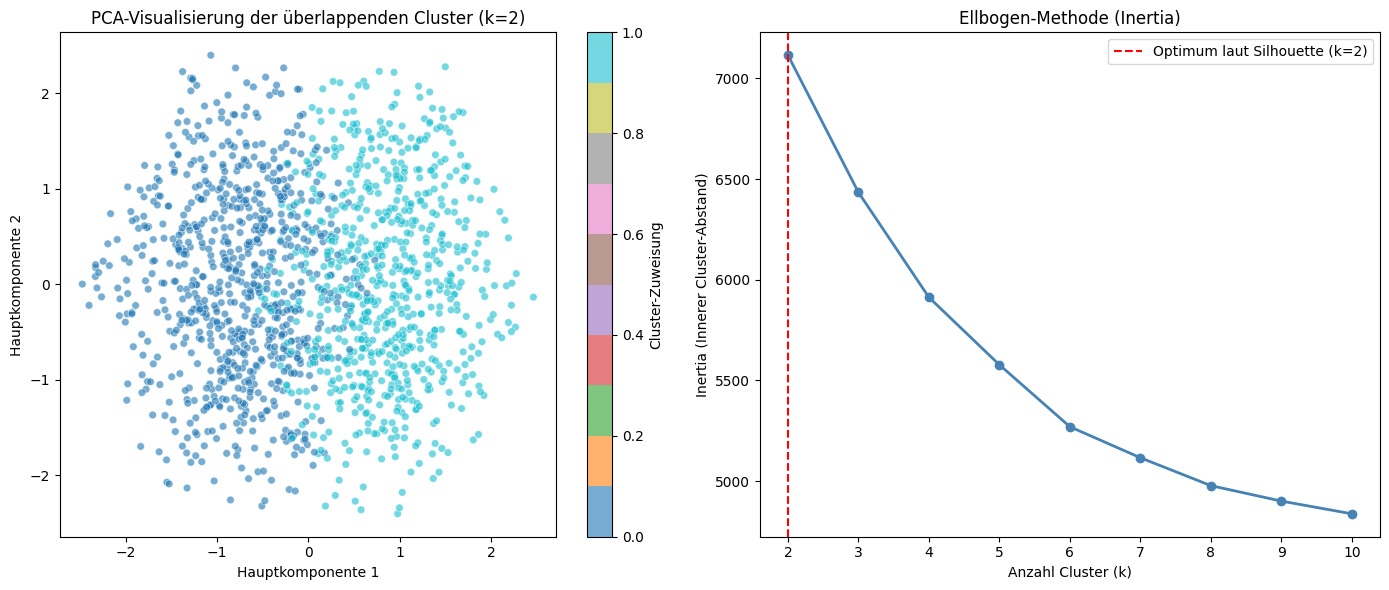

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Feste Stichprobe ziehen (übersichtlicher für den Plot und schneller)
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_full.shape[0], size=1500, replace=False)
X_sample = X_full[sample_idx]

# 2. Werte für den Ellbogen-Graphen berechnen
K_RANGE = range(2, 11)
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels))

best_k_sil = K_RANGE[np.argmax(silhouettes)]

# 3. Finales Clustering mit dem besten k durchführen
km_final = KMeans(n_clusters=best_k_sil, n_init=10, random_state=42)
labels_final = km_final.fit_predict(X_sample)

# 4. PCA berechnen (um die vielen Dimensionen auf 2D für den Plot zu quetschen)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

# 5. Plotten: Beide Diagramme nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LINKER PLOT: Die Cluster ---
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_final, cmap="tab10", 
                          alpha=0.6, s=30, edgecolors='w', linewidth=0.5)
axes[0].set_title(f"PCA-Visualisierung der überlappenden Cluster (k={best_k_sil})")
axes[0].set_xlabel("Hauptkomponente 1")
axes[0].set_ylabel("Hauptkomponente 2")
fig.colorbar(scatter, ax=axes[0], label="Cluster-Zuweisung")

# --- RECHTER PLOT: Der Ellbogen-Graph ---
axes[1].plot(list(K_RANGE), inertias, marker="o", color="steelblue", linewidth=2)
axes[1].set_title("Ellbogen-Methode (Inertia)")
axes[1].set_xlabel("Anzahl Cluster (k)")
axes[1].set_ylabel("Inertia (Innerer Cluster-Abstand)")
# Wir markieren zum Vergleich, wo der Silhouette-Score sein k gewählt hat:
axes[1].axvline(x=best_k_sil, color="red", linestyle="--", 
                label=f"Optimum laut Silhouette (k={best_k_sil})")
axes[1].legend()

plt.tight_layout()
plt.show()